# OUTLIER DETECTION — versione corretta

Modifiche rispetto alla versione originale, in linea con le *Project Guidelines* (Modulo 1 — Outliers):

1. **Top 1% reale**, calcolato con un ranking sugli anomaly score (`percentile`), non delegato ciecamente al parametro `contamination`.
2. **Tre metodi di famiglie diverse**: Isolation Forest (isolation-based), Local Outlier Factor (density-based), Elliptic Envelope (statistico / distanza di Mahalanobis).
3. **Confronto e consenso** tra i tre metodi (voto di maggioranza), con discussione dell'overlap.
4. **Visualizzazione PCA (2D e 3D)** per gli outlier multivariati.
5. **Detection univariata per-feature sulle colonne BIA**, per catturare valori estremi su singola feature che il detector multivariato può mancare per masking/diluizione.
6. **Visualizzazione con una seconda tecnica di riduzione dimensionalità (t-SNE)** (NUOVO) che mostra insieme gli outlier multivariati E quelli univariati BIA, non solo i primi.
7. **Trattamento degli outlier** (missing + imputazione KNN) con **riverifica** che non siano più anomali, né a livello multivariato né univariato.

## 0. Import e caricamento dati

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.impute import KNNImputer
import itertools

In [ ]:
df = pd.read_csv("cmi_internet_clean.csv")

## 1. Preparazione colonne (invariato)

In [ ]:
for col in df.columns:
    if "Zone" in col:
        df[col] = df[col].astype(int)
df["Basic_Demos-Sex"] = df["Basic_Demos-Sex"].astype(int)
df['sii'] = df['sii'].astype(int)
df['BIA-BIA_Activity_Level_num'] = df['BIA-BIA_Activity_Level_num'].astype(int)
df['BIA-BIA_Frame_num'] = df['BIA-BIA_Frame_num'].astype(int)
df['PreInt_EduHx-computerinternet_hoursday'] = df['PreInt_EduHx-computerinternet_hoursday'].astype(int)
df['Basic_Demos-Age'] = df['Basic_Demos-Age'].astype(int)

In [ ]:
cols_integers = [col for col in df.columns if df[col].dtype == 'int64']
cols_integers.remove('PreInt_EduHx-computerinternet_hoursday')
cols_integers.remove('Basic_Demos-Age')

seasonal_cols = [col for col in df.columns if 'Season' in col]
all_cols_to_drop = cols_integers + seasonal_cols

df_detection = df.drop(columns=all_cols_to_drop)
print('Shape usata per outlier detection:', df_detection.shape)

Shape usata per outlier detection: (8460, 38)


In [ ]:
feature_names = df_detection.columns.tolist()
X = df_detection.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 2. Top 1% reale via ranking sugli score

In [ ]:
CONTAMINATION = 0.01
n = len(X_scaled)
n_top = int(np.ceil(CONTAMINATION * n))
print(f'n = {n}, top 1% = {n_top} righe')

n = 8460, top 1% = 85 righe


## 3. Tre metodi da famiglie diverse (multivariato)

In [ ]:
clf_if = IsolationForest(n_estimators=300, contamination=CONTAMINATION, random_state=42)
clf_if.fit(X_scaled)
scores_if = clf_if.decision_function(X_scaled)
thr_if = np.percentile(scores_if, 1)
df['Score_IForest'] = scores_if
df['Outlier_IForest'] = (scores_if <= thr_if).astype(int)
print('Isolation Forest, outlier trovati:', df['Outlier_IForest'].sum())

Isolation Forest, outlier trovati: 85


In [ ]:
clf_lof = LocalOutlierFactor(n_neighbors=30, contamination=CONTAMINATION)
clf_lof.fit_predict(X_scaled)
scores_lof = clf_lof.negative_outlier_factor_
thr_lof = np.percentile(scores_lof, 1)
df['Score_LOF'] = scores_lof
df['Outlier_LOF'] = (scores_lof <= thr_lof).astype(int)
print('LOF, outlier trovati:', df['Outlier_LOF'].sum())

LOF, outlier trovati: 85


In [ ]:
clf_ee = EllipticEnvelope(contamination=CONTAMINATION, random_state=42, support_fraction=0.9)
clf_ee.fit(X_scaled)
scores_ee = clf_ee.decision_function(X_scaled)
thr_ee = np.percentile(scores_ee, 1)
df['Score_EE'] = scores_ee
df['Outlier_EE'] = (scores_ee <= thr_ee).astype(int)
print('Elliptic Envelope, outlier trovati:', df['Outlier_EE'].sum())

Elliptic Envelope, outlier trovati: 85


## 4. Confronto tra i metodi (overlap a coppie + consenso multivariato)

In [ ]:
for a, b in itertools.combinations(['Outlier_IForest', 'Outlier_LOF', 'Outlier_EE'], 2):
    overlap = ((df[a] == 1) & (df[b] == 1)).sum()
    print(f'{a} - {b}: {overlap} record in comune (su {n_top})')

df['Outlier_Votes'] = df[['Outlier_IForest', 'Outlier_LOF', 'Outlier_EE']].sum(axis=1)
df['Outlier_Confermato'] = (df['Outlier_Votes'] >= 2).astype(int)

print('\nConfermati da almeno 2 metodi su 3 (multivariato):', df['Outlier_Confermato'].sum())
print('Confermati da tutti e 3 i metodi:   ', (df['Outlier_Votes'] == 3).sum())

Outlier_IForest - Outlier_LOF: 0 record in comune (su 85)
Outlier_IForest - Outlier_EE: 11 record in comune (su 85)
Outlier_LOF - Outlier_EE: 14 record in comune (su 85)

Confermati da almeno 2 metodi su 3 (multivariato): 25
Confermati da tutti e 3 i metodi:    0


## 5. Visualizzazione PCA (2D e 3D) — solo flag multivariato

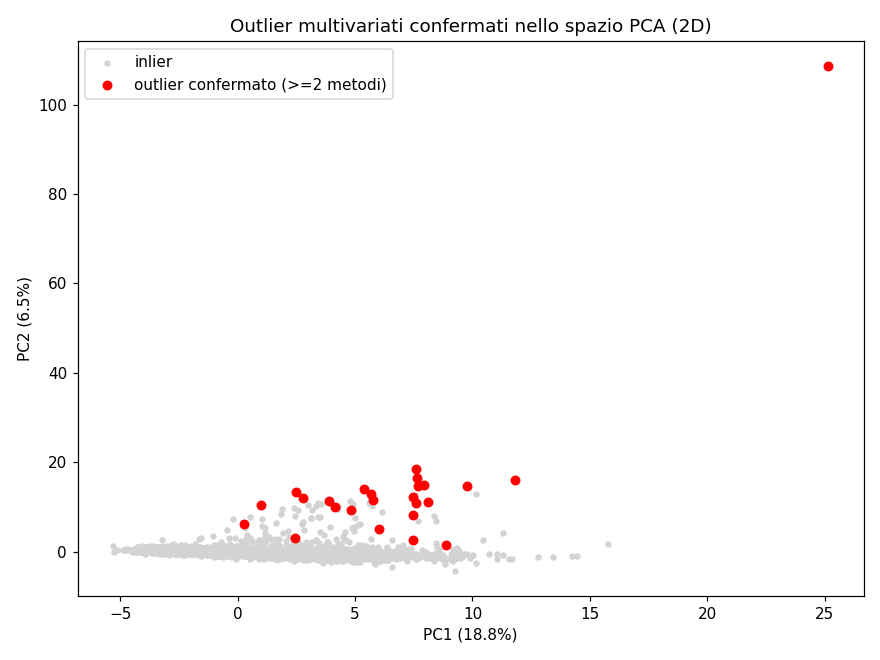

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
mask_mv = df['Outlier_Confermato'] == 1

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[~mask_mv, 0], X_pca[~mask_mv, 1], c='lightgray', s=10, label='inlier')
plt.scatter(X_pca[mask_mv, 0], X_pca[mask_mv, 1], c='red', s=30, label='outlier confermato (>=2 metodi)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Outlier multivariati confermati nello spazio PCA (2D)')
plt.legend()
plt.tight_layout()
plt.show()

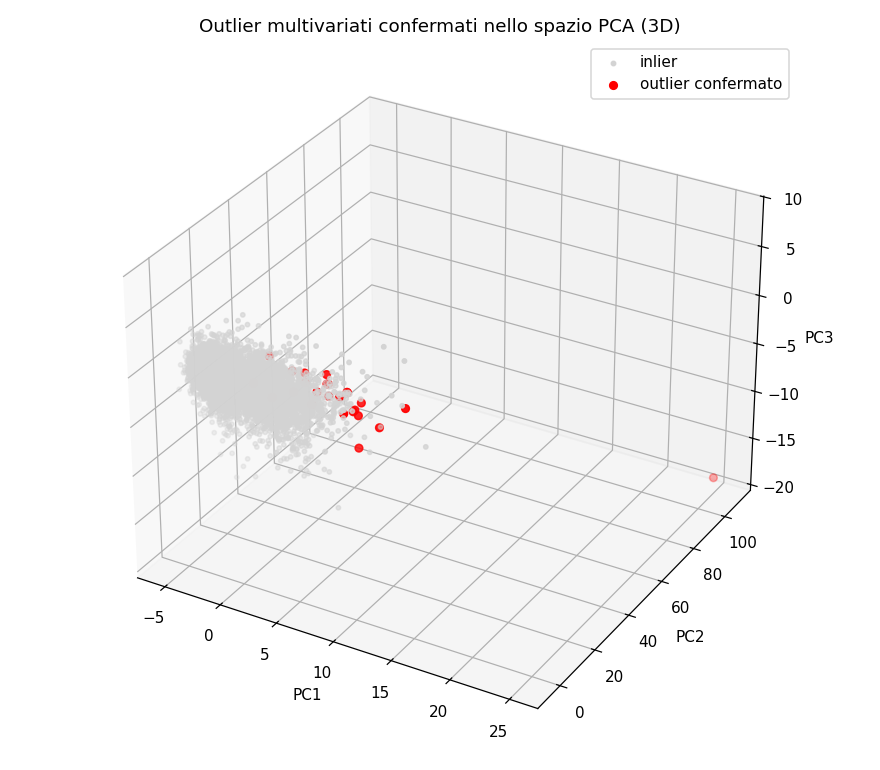

In [ ]:
pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca3[~mask_mv, 0], X_pca3[~mask_mv, 1], X_pca3[~mask_mv, 2], c='lightgray', s=8, label='inlier')
ax.scatter(X_pca3[mask_mv, 0], X_pca3[mask_mv, 1], X_pca3[mask_mv, 2], c='red', s=25, label='outlier confermato')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.set_title('Outlier multivariati confermati nello spazio PCA (3D)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Detection univariata per-feature sulle colonne BIA

Le feature di composizione corporea (`BIA-*`) sono fortemente *right-skewed*: mediana bassa e coda destra con valori altissimi (es. `BIA-BIA_DEE`, dispendio energetico, arriva a **124.728** contro una mediana di **1839** — fisiologicamente impossibile, quasi certamente un errore di inserimento dati).

Il detector multivariato può mancarle per due motivi:
- **masking effect**: `StandardScaler` calcola media/std sugli stessi dati che contengono l'outlier, che quindi gonfia la std e comprime il proprio z-score;
- **diluizione da alta dimensionalità**: una riga estrema su *una sola* delle 38 feature ha una distanza/isolamento complessivo che può non bastare a entrare nel top 1% globale.

**Fix**: per ogni colonna BIA, flag del **top 0.1% dei valori più alti** (solo coda destra), poi unione tra le colonne.

In [ ]:
bia_cols = [c for c in df_detection.columns if 'BIA' in c]
print('Colonne BIA usate per la detection univariata:', bia_cols)

PERCENTILE_CUTOFF = 0.999  # top 0.1% per colonna

univariate_flags = pd.DataFrame({
    col: df[col] > df[col].quantile(PERCENTILE_CUTOFF) for col in bia_cols
})
df['Outlier_Univariato_BIA'] = univariate_flags.any(axis=1).astype(int)
df['N_Feature_BIA_Anomale'] = univariate_flags.sum(axis=1)

print(f"Record con almeno una feature BIA nel top 0.1% (coda alta): {df['Outlier_Univariato_BIA'].sum()} "
      f"({df['Outlier_Univariato_BIA'].mean()*100:.2f}% del dataset)")
print('Di questi, già intercettati dalla detection multivariata:',
      ((df['Outlier_Univariato_BIA']==1) & (df['Outlier_Confermato']==1)).sum())
print('Nuovi (mancati dalla detection multivariata):',
      ((df['Outlier_Univariato_BIA']==1) & (df['Outlier_Confermato']==0)).sum())

Colonne BIA usate per la detection univariata: ['BIA-BIA_BMC', 'BIA-BIA_BMI', 'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'BIA-BIA_TBW']
Record con almeno una feature BIA nel top 0.1% (coda alta): 104 (1.23% del dataset)
Di questi, già intercettati dalla detection multivariata: 21
Nuovi (mancati dalla detection multivariata): 83


In [ ]:
df['Outlier_Finale'] = ((df['Outlier_Confermato'] == 1) | (df['Outlier_Univariato_BIA'] == 1)).astype(int)
print('Outlier finali da trattare (multivariato OR univariato BIA):', df['Outlier_Finale'].sum(),
      f"({df['Outlier_Finale'].mean()*100:.2f}% del dataset)")

Outlier finali da trattare (multivariato OR univariato BIA): 108 (1.28% del dataset)


## 7. NUOVO — Visualizzazione con una seconda tecnica di riduzione dimensionalità (t-SNE)

La PCA (sezione 5) mostrava **solo** gli outlier multivariati — incompleto, perché ignora completamente gli 83 record trovati dall'analisi univariata BIA. Qui si usa **t-SNE** (tecnica non lineare, complementare alla PCA che è lineare) per proiettare in 2D **tutti e 38** i punti, distinguendo quattro categorie: inlier, outlier trovati solo dal multivariato, solo dall'univariato BIA, o da entrambi.

inlier                 8352
solo univariato BIA      83
entrambi                 21
solo multivariato         4
Name: count, dtype: int64


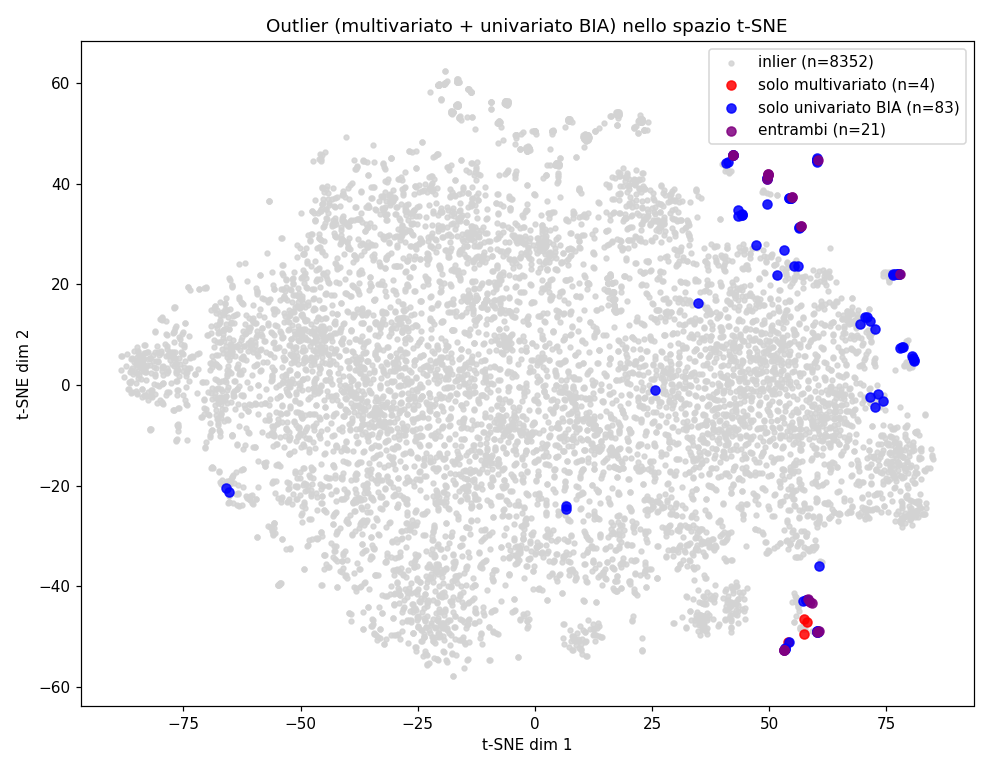

In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled)

cat = pd.Series('inlier', index=df.index)
cat[(df['Outlier_Confermato']==1) & (df['Outlier_Univariato_BIA']==0)] = 'solo multivariato'
cat[(df['Outlier_Confermato']==0) & (df['Outlier_Univariato_BIA']==1)] = 'solo univariato BIA'
cat[(df['Outlier_Confermato']==1) & (df['Outlier_Univariato_BIA']==1)] = 'entrambi'
print(cat.value_counts())

colors = {'inlier':'lightgray','solo multivariato':'red','solo univariato BIA':'blue','entrambi':'purple'}
plt.figure(figsize=(9, 7))
for c, color in colors.items():
    m = (cat == c).values
    plt.scatter(X_tsne[m, 0], X_tsne[m, 1], c=color, s=(10 if c=='inlier' else 35),
                label=f'{c} (n={m.sum()})', alpha=0.85)
plt.xlabel('t-SNE dim 1'); plt.ylabel('t-SNE dim 2')
plt.title('Outlier (multivariato + univariato BIA) nello spazio t-SNE')
plt.legend()
plt.tight_layout()
plt.show()

Il t-SNE mostra bene la differenza tra le due famiglie di anomalie: gli outlier **"solo multivariato"** e quelli **"entrambi"** tendono a raggrupparsi in poche zone isolate ai bordi della nuvola di punti (anomalie globali su più dimensioni contemporaneamente), mentre gli outlier **"solo univariato BIA"** (in blu) sono sparsi in diverse zone della mappa — spesso vicini a punti inlier — perché sono anomali su una singola feature ma altrove nella norma, esattamente il tipo di punto che una detection puramente multivariata tende a non isolare.

## 8. Trattamento degli outlier + riverifica (sul flag finale = unione dei due approcci)

In [ ]:
df_treated = df_detection.copy()
outlier_idx = df.index[df['Outlier_Finale'] == 1]
print('Record trattati come missing (totale):', len(outlier_idx))

df_treated.loc[outlier_idx, :] = np.nan

imputer = KNNImputer(n_neighbors=5)
X_treated_imputed = imputer.fit_transform(df_treated)
X_treated_scaled = StandardScaler().fit_transform(X_treated_imputed)

df_imputed = pd.DataFrame(X_treated_imputed, columns=df_detection.columns, index=df_detection.index)

df['Basic_Demos-Age'] = df['Basic_Demos-Age'].astype(float)
df['PreInt_EduHx-computerinternet_hoursday'] = df['PreInt_EduHx-computerinternet_hoursday'].astype(float)

df.loc[outlier_idx, df_detection.columns] = df_imputed.loc[outlier_idx]

df['Basic_Demos-Age'] = df['Basic_Demos-Age'].round().astype(int)
df['PreInt_EduHx-computerinternet_hoursday'] = df['PreInt_EduHx-computerinternet_hoursday'].round().astype(int)

Record trattati come missing (totale): 108


In [ ]:
clf_check = IsolationForest(n_estimators=300, contamination=CONTAMINATION, random_state=42)
clf_check.fit(X_treated_scaled)
scores_check = clf_check.decision_function(X_treated_scaled)
thr_check = np.percentile(scores_check, 1)
pos = df.index.get_indexer(outlier_idx)
still_outlier_mv = (scores_check[pos] <= thr_check).sum()
print(f"Dei {len(outlier_idx)} punti trattati, ancora outlier MULTIVARIATO dopo l'imputazione: {still_outlier_mv}")

orig_quantiles = {c: df.loc[df.index.difference(outlier_idx), c].quantile(PERCENTILE_CUTOFF) for c in bia_cols}
still_flags = pd.DataFrame({c: df.loc[outlier_idx, c] > orig_quantiles[c] for c in bia_cols})
still_outlier_uni = still_flags.any(axis=1).sum()
print(f"Dei {len(outlier_idx)} punti trattati, ancora outlier UNIVARIATO BIA dopo l'imputazione: {still_outlier_uni}")

Dei 108 punti trattati, ancora outlier MULTIVARIATO dopo l'imputazione: 0
Dei 108 punti trattati, ancora outlier UNIVARIATO BIA dopo l'imputazione: 0


In [ ]:
diagnostic_cols = ['Score_IForest', 'Outlier_IForest', 'Score_LOF', 'Outlier_LOF',
                    'Score_EE', 'Outlier_EE', 'Outlier_Votes', 'Outlier_Confermato',
                    'Outlier_Univariato_BIA', 'N_Feature_BIA_Anomale', 'Outlier_Finale']

df.drop(columns=diagnostic_cols).to_csv("cmi_internet_outliers_flagged.csv", index=False)
print("Salvato.")

Salvato.
